# OpenWInD-Mundstückkalibrierung für eine Sopran-D-Whistle


Die Kalibrierung minimiert die Abweichung des ersten Impedanzmaximums vom gemessenen D5. Anschließend wird geprüft, wie gut das zweite Maximum die gemessene Oktave D6 reproduziert. Die Implementierung verwendet die im lokalen Checkout verfügbare OpenWInD-Schnittstelle `ImpedanceComputation`; falls eine zukünftige OpenWInD-Version `Instrument` oder `Simu` exportiert, werden diese Symbole zusätzlich importiert.

In [20]:
from __future__ import annotations

import json
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
from scipy import signal
from scipy.optimize import minimize_scalar

try:
    from openwind import Instrument, Player, Simu
except ImportError:
    from openwind import Player, ImpedanceComputation
    Instrument = None
    Simu = None

try:
    from openwind import ImpedanceComputation
except ImportError as exc:
    raise ImportError(
        'Dieses Notebook benötigt die lokale OpenWInD-Installation.'
    ) from exc

print(f'OpenWInD-Kompatibilität: Instrument={Instrument is not None}, Simu={Simu is not None}')

OpenWInD-Kompatibilität: Instrument=False, Simu=False


## 2. Konfiguration und Messwerte



In [21]:
R_BORE = 0.0072
L_PHYSICAL = 0.26361
TARGET_F1_D5 = 587.33
TARGET_F2_D6 = 1174.66
TEMPERATURE = 20.0

L_MOUTH_BOUNDS = (0.005, 0.040)
FREQUENCY_RANGE = (300.0, 2000.0)
N_POINTS = 2000
OUTPUT_PATH = Path('calibrated_whistle_parameters.json')

print(f'Bohrungsdurchmesser: {2 * R_BORE * 1000:.1f} mm')
print(f'Physische Rohrlänge: {L_PHYSICAL * 1000:.2f} mm')

Bohrungsdurchmesser: 14.4 mm
Physische Rohrlänge: 263.61 mm


## 3. OpenWInD-Instrumentgenerator



In [22]:
@dataclass
class WhistleInstrument:
    bore: list[tuple[float, float]]
    radiation: str = 'unflanged'
    temperature: float = TEMPERATURE

    def get_impedance(self, frequencies: np.ndarray) -> np.ndarray:
        computation = ImpedanceComputation(
            frequencies=frequencies,
            main_bore=self.bore,
            unit='m',
            temperature=self.temperature,
            radiation_category=self.radiation,
            player=Player('UNITARY_FLOW'),
            compute_method='TMM',
            losses=True,
            nondim=False,
        )
        return np.asarray(computation.impedance, dtype=complex)


def create_whistle_model(L_mouth: float) -> WhistleInstrument:
    '''Create a constant-radius whistle with an acoustic mouthpiece extension.'''
    if not L_MOUTH_BOUNDS[0] <= L_mouth <= L_MOUTH_BOUNDS[1]:
        raise ValueError(f'L_mouth must be in {L_MOUTH_BOUNDS} m, got {L_mouth}.')
    bore = [
        (0.0, R_BORE),
        (L_mouth, R_BORE),
        (L_mouth + L_PHYSICAL, R_BORE),
    ]
    return WhistleInstrument(bore=bore)

## 4. Impedanzspektrum und Peak-Erkennung



In [23]:
def get_impedance_peaks(
    instrument: WhistleInstrument,
    f_min: float = 300.0,
    f_max: float = 2000.0,
    n_points: int = 2000,
) -> tuple[float, float, np.ndarray, np.ndarray]:
    '''Return the first two play resonances (admittance peaks / impedance minima) and the full complex spectrum.'''
    frequencies = np.linspace(f_min, f_max, n_points)
    impedance = instrument.get_impedance(frequencies)
    magnitude = np.abs(impedance)
    finite = np.isfinite(magnitude)

    if not np.any(finite):
        raise RuntimeError('OpenWInD returned no finite impedance values.')

    safe_magnitude = np.nan_to_num(magnitude, nan=0.0, posinf=0.0, neginf=0.0)

    # Admittance peaks correspond to the flute's play resonances.
    with np.errstate(divide='ignore'):
        admittance = np.where(safe_magnitude > 0, 1.0 / safe_magnitude, 0.0)

    safe_admittance = np.nan_to_num(admittance, nan=0.0, posinf=0.0, neginf=0.0)
    prominence = max(float(np.nanmax(safe_admittance)) * 1e-4, 1e-12)

    peak_indices, _ = signal.find_peaks(safe_admittance, prominence=prominence)
    peak_indices = peak_indices[np.argsort(frequencies[peak_indices])]

    if len(peak_indices) < 2:
        windows = ((f_min, 0.9 * TARGET_F1_D5), (0.9 * TARGET_F1_D5, f_max))
        fallback = []
        for low, high in windows:
            mask = (frequencies >= low) & (frequencies <= high) & finite
            if np.any(mask):
                # Fallback: maximum admittance within each search window.
                local = np.flatnonzero(mask)[np.argmax(safe_admittance[mask])]
                fallback.append(local)
        peak_indices = np.unique(fallback)

    if len(peak_indices) < 2:
        raise RuntimeError('Weniger als zwei Spiel-Resonanzen (Admittanzpeaks) gefunden.')

    return (
        float(frequencies[peak_indices[0]]),
        float(frequencies[peak_indices[1]]),
        frequencies,
        impedance,
    )

## 5. Automatische Kalibrierung



In [24]:
def objective(L_mouth: float) -> float:
    try:
        f1, _, _, _ = get_impedance_peaks(create_whistle_model(float(L_mouth)))
        return abs(f1 - TARGET_F1_D5)
    except (RuntimeError, ValueError, FloatingPointError) as exc:
        warnings.warn(f'Peak search failed at {L_mouth * 1000:.2f} mm: {exc}')
        return 1e9

calibration = minimize_scalar(
    objective, bounds=L_MOUTH_BOUNDS, method='bounded',
    options={'xatol': 1e-7, 'maxiter': 60},
)
if not calibration.success:
    warnings.warn(f'Optimierung meldet: {calibration.message}')
L_mouth_opt = float(calibration.x)
f1_opt, f2_opt, frequencies, impedance = get_impedance_peaks(create_whistle_model(L_mouth_opt))
f1_cents = 1200.0 * np.log2(f1_opt / TARGET_F1_D5)
print(f'Kalibriertes L_mouth: {L_mouth_opt * 1000:.3f} mm')
print(f'f1 simuliert: {f1_opt:.2f} Hz | Ziel D5: {TARGET_F1_D5:.2f} Hz | Fehler: {f1_cents:+.2f} cents')

Kalibriertes L_mouth: 21.991 mm
f1 simuliert: 587.44 Hz | Ziel D5: 587.33 Hz | Fehler: +0.34 cents


## 6. Validierung der Oktave

Für eine ideale Oktave wäre $f_2/f_1=2$. Die Abweichung in Cent trennt dabei die absolute Kalibrierung des Grundtons von der Registertreue des vereinfachten Mundstück-/Rohrmodells.

In [25]:
octave_ratio = f2_opt / f1_opt
octave_cents = 1200.0 * np.log2(octave_ratio / 2.0)
f2_target_cents = 1200.0 * np.log2(f2_opt / TARGET_F2_D6)
print(f'f2 simuliert: {f2_opt:.2f} Hz | Ziel D6: {TARGET_F2_D6:.2f} Hz | Fehler: {f2_target_cents:+.2f} cents')
print(f'Oktavverhältnis f2/f1: {octave_ratio:.6f}')
print(f'Abweichung von der reinen Oktave: {octave_cents:+.2f} cents')
print('Oktavintervall innerhalb von 5 cents.' if abs(octave_cents) <= 5 else 'Oktavintervall weicht um mehr als 5 cents ab.')

f2 simuliert: 1178.49 Hz | Ziel D6: 1174.66 Hz | Fehler: +5.63 cents
Oktavverhältnis f2/f1: 2.006131
Abweichung von der reinen Oktave: +5.30 cents
Oktavintervall weicht um mehr als 5 cents ab.


## 7. Publikationsfähige Darstellung

Die obere Achse zeigt den Betrag der Eingangsimpedanz, die untere deren Phase. Die gestrichelten Linien markieren sowohl die simulierten Resonanzen als auch die Messwerte, sodass absolute und relative Abweichungen direkt sichtbar sind.

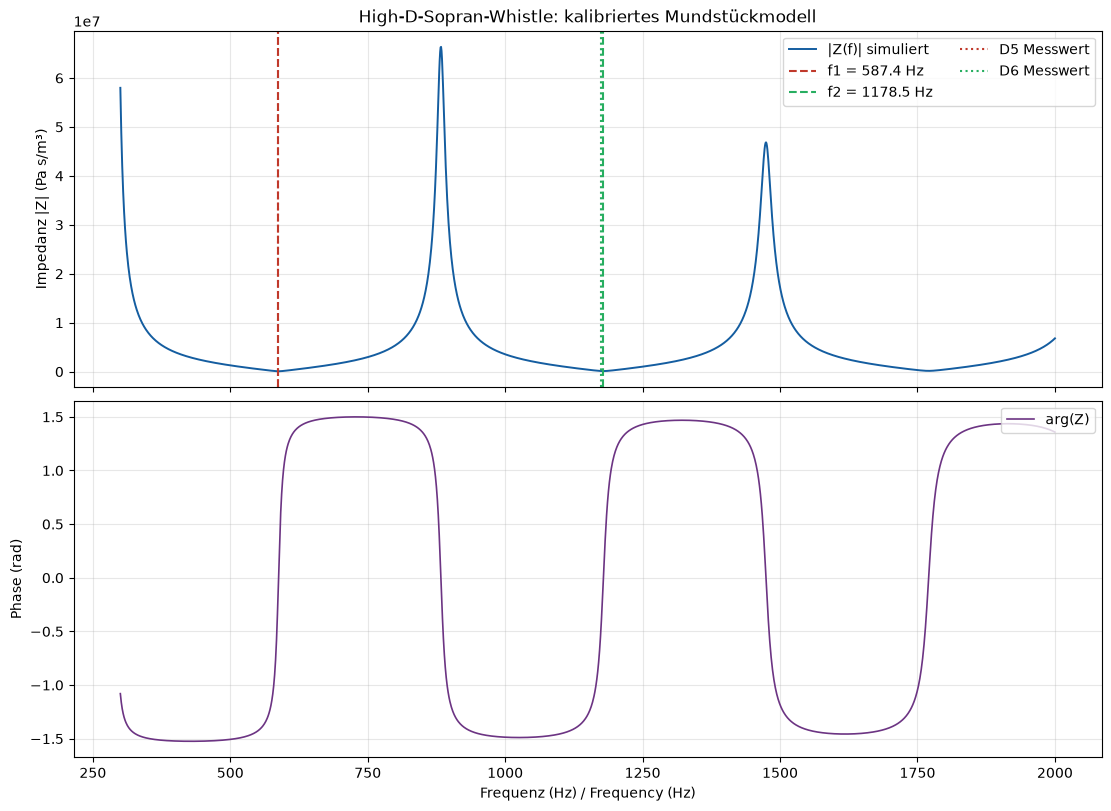

In [26]:
magnitude = np.abs(impedance)
phase = np.unwrap(np.angle(impedance))
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True, constrained_layout=True)
axes[0].plot(frequencies, magnitude, color='#145da0', linewidth=1.4, label='|Z(f)| simuliert')
axes[0].axvline(f1_opt, color='#c0392b', linestyle='--', label=f'f1 = {f1_opt:.1f} Hz')
axes[0].axvline(f2_opt, color='#27ae60', linestyle='--', label=f'f2 = {f2_opt:.1f} Hz')
axes[0].axvline(TARGET_F1_D5, color='#c0392b', linestyle=':', label='D5 Messwert')
axes[0].axvline(TARGET_F2_D6, color='#27ae60', linestyle=':', label='D6 Messwert')
axes[0].set_ylabel('Impedanz |Z| (Pa s/m³)')
axes[0].set_title('High-D-Sopran-Whistle: kalibriertes Mundstückmodell')
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc='upper right', ncol=2)
axes[1].plot(frequencies, phase, color='#6c3483', linewidth=1.2, label='arg(Z)')
axes[1].set_xlabel('Frequenz (Hz) / Frequency (Hz)')
axes[1].set_ylabel('Phase (rad)')
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc='upper right')
plt.show()

## 8. Export für die weitere Tonlochoptimierung

Die Parameterdatei enthält nur serialisierbare Geometrie- und Kalibrierwerte. Der gezeigte Anschlusscode kann in einer Optimierung mit `OptimProblem` beziehungsweise der entsprechenden Optimierungs-API der verwendeten OpenWInD-Version als Ausgangspunkt dienen.

In [27]:
export_data: dict[str, Any] = {
    'instrument': 'High D soprano tin whistle',
    'bore_radius_m': R_BORE,
    'physical_length_m': L_PHYSICAL,
    'mouthpiece_length_m': L_mouth_opt,
    'temperature_c': TEMPERATURE,
    'radiation': 'unflanged',
    'calibration': {
        'target_f1_hz': TARGET_F1_D5,
        'simulated_f1_hz': f1_opt,
        'target_f2_hz': TARGET_F2_D6,
        'simulated_f2_hz': f2_opt,
        'octave_deviation_cents': octave_cents,
    },
}
OUTPUT_PATH.write_text(json.dumps(export_data, indent=2), encoding='utf-8')
print(f'Gespeichert: {OUTPUT_PATH.resolve()}')

print('''
# Anschluss an eine OpenWInD-Tonlochoptimierung (API je nach Version anpassen):
from pathlib import Path
import json
from openwind import OptimProblem

params = json.loads(Path("calibrated_whistle_parameters.json").read_text())
model = create_whistle_model(params["mouthpiece_length_m"])
# problem = OptimProblem(model, variables={"hole_1_position": 0.08, ...})
# problem.solve()
''')

Gespeichert: C:\projects\p\openWind\notebooks\calibrated_whistle_parameters.json

# Anschluss an eine OpenWInD-Tonlochoptimierung (API je nach Version anpassen):
from pathlib import Path
import json
from openwind import OptimProblem

params = json.loads(Path("calibrated_whistle_parameters.json").read_text())
model = create_whistle_model(params["mouthpiece_length_m"])
# problem = OptimProblem(model, variables={"hole_1_position": 0.08, ...})
# problem.solve()

